# Whisper Audio Analysis

**Welcome to Modal Notebooks!**

This notebook sets you up with OpenAI's [Whisper](https://github.com/openai/whisper)
speech recognition model. In addition to running Whisper, it also visualizes the attention
weights over time in PyTorch, based on code modified from
[this source](https://github.com/openai/whisper/blob/main/notebooks/Multilingual_ASR.ipynb).

We've initialized this notebook with an **Nvidia T4 GPU**, which you can
see in the Kernel settings panel on the left sidebar. Don't worry though,
_you only pay while the notebook is running_, and it automatically shuts down
when not in use. [Check your usage](https://modal.com/settings/usage) at any point.

Modal users receive $30 in free credits per month. Let's get started.

In [ ]:
'''
# shortest way
!pip install --upgrade --quiet --no-deps openai-whisper
import whisper
# To ensure a fresh import after installation, sometimes restarting the runtime is needed.
# If this still fails, please try restarting the Colab runtime (Runtime -> Restart runtime) and then run the cell again.
model = whisper.load_model("medium")
result = model.transcribe("/content/audio_sample/Gunjan_sir_audio.mp3")
print(result["text"])
'''
!apt install -y -qq ffmpeg

ffmpeg is already the newest version (7:5.1.6-0+deb12u1).
0 upgraded, 0 newly installed, 0 to remove and 50 not upgraded.


In [48]:
%uv pip install openai-whisper dtw-python

Using Python 3.12.6 environment at: /usr/local
Audited 2 packages in 16ms
Note: you may need to restart the kernel to use updated packages.


In [49]:
import string
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import torch
import whisper
from dtw import dtw
from IPython.display import Audio, display
from scipy.ndimage import median_filter

## Audio transcription

We'll download a sample audio file to run Whisper transcription on.

Or, feel free to upload a custom audio file, which will be used instead. You just
need to drag-and-drop it into the file viewer on the left side, then change the
`filename` variable in the cell below.

In [50]:
!wget -qO pearlharbor.ogg "https://upload.wikimedia.org/wikipedia/commons/4/46/1941_Roosevelt_speech_pearlharbor_p1.ogg"

filename = "pearlharbor.ogg"
Audio(Path(filename).read_bytes())

Audio duration: 417649


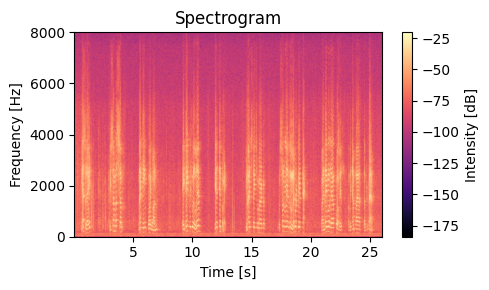

In [51]:
audio: torch.Tensor = whisper.load_audio(filename)
print("Audio duration:", audio.shape[0])

plt.figure(figsize=(5, 3))
plt.specgram(audio, NFFT=1024, Fs=16000, noverlap=512, cmap="magma")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label="Intensity [dB]")
plt.title("Spectrogram")
plt.tight_layout()
plt.show()

Now we'll load Whisper. There a few Whisper models, but for the sake of this
notebook, their small "base" model with 74M parameters will be fine for now.
This can be loaded relatively quickly in float32 format.

Once the model is loaded, `model.transcribe()` is all you need to get text.

In [52]:
model = whisper.load_model("base")

In [53]:
result = model.transcribe(audio)
transcription = result["text"]
print(transcription)

 Yesterday, December 7, 1941, a date which will live in infamy. The United States of America was suddenly and deliberately attacked by naval and air forces of the Empire of Japan.


## Analyzing attention weights

Great! Now that we've run Whisper, we can try visualizing the weights.
Modal Notebooks are great for experimenting on GPUs with live models,
and in this case, you can edit the model's intermediate layers to install
hooks for retrieving attention tensors.

The resulting weights can be plotted to show the estimated contribution
of different parts of the audio to each transcribed text token.

In [54]:
AUDIO_SAMPLES_PER_TOKEN = whisper.audio.HOP_LENGTH * 2
AUDIO_TIME_PER_TOKEN = AUDIO_SAMPLES_PER_TOKEN / whisper.audio.SAMPLE_RATE

medfilt_width = 7
qk_scale = 1.0

language = "English"
tokenizer = whisper.tokenizer.get_tokenizer(model.is_multilingual, language=language)

In [55]:
# install hooks on the cross attention layers to retrieve the attention weights
#
# needs whisper.modal.disable_sdpa() to be set in context, otherwise attention
# weights are not returned (scaled dot-product attention kernel)
QKs = [None] * model.dims.n_text_layer

for i, block in enumerate(model.decoder.blocks):

    def _forward_hook(_, ins, outs, index=i):
        QKs[index] = outs[-1]
        return outs

    block.cross_attn.register_forward_hook(_forward_hook)

In [56]:
def split_tokens_on_unicode(tokens: torch.Tensor):
    words = []
    word_tokens = []
    current_tokens = []

    for token in tokens.tolist():
        current_tokens.append(token)
        decoded = tokenizer.decode_with_timestamps(current_tokens)
        if "\ufffd" not in decoded:
            words.append(decoded)
            word_tokens.append(current_tokens)
            current_tokens = []

    return words, word_tokens


def split_tokens_on_spaces(tokens: torch.Tensor):
    subwords, subword_tokens_list = split_tokens_on_unicode(tokens)
    words = []
    word_tokens = []

    for subword, subword_tokens in zip(subwords, subword_tokens_list):
        special = subword_tokens[0] >= tokenizer.eot
        with_space = subword.startswith(" ")
        punctuation = subword.strip() in string.punctuation
        if special or with_space or punctuation:
            words.append(subword)
            word_tokens.append(subword_tokens)
        else:
            words[-1] = words[-1] + subword
            word_tokens[-1].extend(subword_tokens)

    return words, word_tokens


if language in {"Chinese", "Japanese", "Thai", "Lao", "Myanmar"}:
    # These languages don't typically use spaces, so it is difficult to split words
    # without morpheme analysis. Here, we instead split words at any
    # position where the tokens are decoded as valid unicode points
    split_tokens = split_tokens_on_unicode
else:
    split_tokens = split_tokens_on_spaces

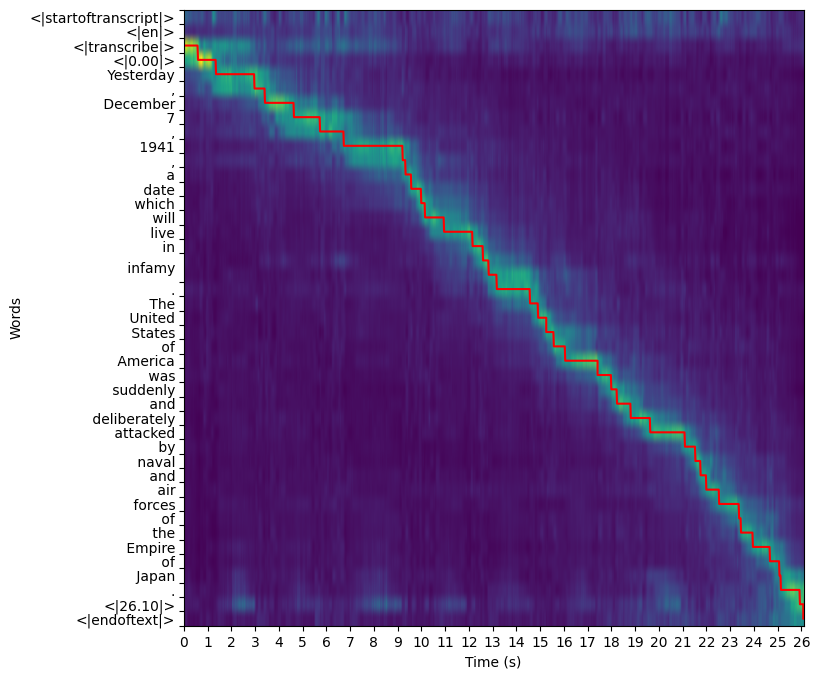

,word,begin,end
0,Yesterday,1.36,2.98
1,December,3.42,4.64
2,7,4.64,5.74
3,1941,6.74,9.22
4,a,9.34,9.58
5,date,9.58,10.00
6,which,10.00,10.16
7,will,10.16,10.96
8,live,10.96,12.16
9,in,12.16,12.60


In [57]:
duration = len(audio)
mel = whisper.log_mel_spectrogram(whisper.pad_or_trim(audio), n_mels=model.dims.n_mels).cuda()
tokens = torch.tensor(
    [
        *tokenizer.sot_sequence,
        tokenizer.timestamp_begin,
    ]
    + tokenizer.encode(transcription)
    + [
        tokenizer.timestamp_begin + duration // AUDIO_SAMPLES_PER_TOKEN,
        tokenizer.eot,
    ]
).cuda()
with torch.no_grad(), whisper.model.disable_sdpa():
    logits = model(mel.unsqueeze(0), tokens.unsqueeze(0))

weights = torch.cat(QKs)  # layers * heads * tokens * frames
weights = weights[:, :, :, : duration // AUDIO_SAMPLES_PER_TOKEN].cpu()
weights = median_filter(weights, (1, 1, 1, medfilt_width))
weights = torch.tensor(weights * qk_scale).softmax(dim=-1)

w = weights / weights.norm(dim=-2, keepdim=True)
matrix = w[-6:].mean(axis=(0, 1))

alignment = dtw(-matrix.double().numpy())

jumps = np.pad(np.diff(alignment.index1s), (1, 0), constant_values=1).astype(bool)
jump_times = alignment.index2s[jumps] * AUDIO_TIME_PER_TOKEN
words, word_tokens = split_tokens(tokens)

# display the normalized attention weights and the alignment
plt.figure(figsize=(8, 8))
plt.imshow(matrix, aspect="auto")
plt.plot(alignment.index2s, alignment.index1s, color="red")

xticks = np.arange(0, matrix.shape[1], 1 / AUDIO_TIME_PER_TOKEN)
xticklabels = (xticks * AUDIO_TIME_PER_TOKEN).round().astype(np.int32)
plt.xticks(xticks, xticklabels)
plt.xlabel("Time (s)")

# display tokens and words as tick labels
ylims = plt.gca().get_ylim()

ax = plt.gca()
ax.tick_params("both", length=0, width=0, which="minor", pad=6)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")
ax.invert_yaxis()
ax.set_ylim(ylims)

major_ticks = [-0.5]
minor_ticks = []
current_y = 0

for word, word_token in zip(words, word_tokens):
    minor_ticks.append(current_y + len(word_token) / 2 - 0.5)
    current_y += len(word_token)
    major_ticks.append(current_y - 0.5)

ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(ticker.FixedFormatter(words))
ax.set_yticks(major_ticks)
ax.yaxis.set_major_formatter(ticker.NullFormatter())

plt.ylabel("Words")
plt.show()

# display the word-level timestamps in a table
word_boundaries = np.pad(np.cumsum([len(t) for t in word_tokens[:-1]]), (1, 0))
begin_times = jump_times[word_boundaries[:-1]]
end_times = jump_times[word_boundaries[1:]]

data = [
    dict(word=word, begin=begin, end=end)
    for word, begin, end in zip(words[:-1], begin_times, end_times)
    if not word.startswith("<|") and word.strip() not in ".,!?、。"
]

display(pd.DataFrame(data))

## Conclusion

That's all for this example. Next, check out the docs on
[Modal Notebooks](https://modal.com/docs/guide/notebooks), or try
sharing the notebook on the top-right.